<a href="https://colab.research.google.com/github/jmurarka/fake-ai-news/blob/main/detect_ai_generated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedrcat/daigt-v2-train-dataset")

print("Path to dataset files:", path)

100%|██████████| 28.5M/28.5M [00:00<00:00, 66.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thedrcat/daigt-v2-train-dataset/versions/2


In [ ]:
import pandas as pd

In [ ]:
# df1 = pd.read_csv(path + "/train_v2_drcat_02.csv")
# df1.head()

NameError: name 'pd' is not defined

In [ ]:
# new_df1 = df1.drop(columns=["prompt_name", "source", "RDizzl3_seven"])
# new_df1.head()

In [ ]:
# new_df1.shape

0 - human
1 - ai

In [ ]:
import kagglehub

# Download latest version
path2 = kagglehub.dataset_download("shanegerami/ai-vs-human-text")

print("Path to dataset files:", path2)

In [ ]:
import pandas as pd
df2 = pd.read_csv(path2 + "/AI_Human.csv")
df2.head()

In [ ]:
df2["generated"] = df2["generated"].astype(int)
df2 = df2.rename(columns={"generated": "label"})

In [ ]:
df2.head()

,text,label
0,Cars. Cars have been around since they became ...,0
1,Transportation is a large necessity in most co...,0
2,"""America's love affair with it's vehicles seem...",0
3,How often do you ride in a car? Do you drive a...,0
4,Cars are a wonderful thing. They are perhaps o...,0


In [ ]:
df2.shape

(487235, 2)

In [ ]:
# random sample of 100 rows
sample_df = df2.sample(n=100, random_state=42)

# average length of the text column
avg_length = sample_df['text'].str.len().mean()

print(avg_length)

2255.32


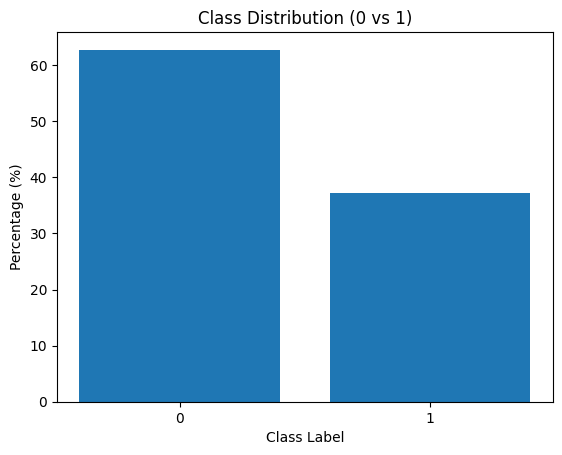

In [ ]:
import matplotlib.pyplot as plt

counts = df2['label'].value_counts(normalize=True) * 100

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Class Label")
plt.ylabel("Percentage (%)")
plt.title("Class Distribution (0 vs 1)")
plt.show()

In [ ]:
label_counts = df2['label'].value_counts(normalize=True) * 100
print(label_counts)

label
0    62.761706
1    37.238294
Name: proportion, dtype: float64


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
# path3 = "/content/drive/My Drive/DATASET/llm-detect-ai-generated-text"
# df3 = pd.read_csv(path3 + "/train_essays.csv")
# df3.head()


In [ ]:
# new_df3 = df3.drop(columns=["id","prompt_id"])
# new_df3.head()

,text,generated
0,Cars. Cars have been around since they became ...,0
1,Transportation is a large necessity in most co...,0
2,"""America's love affair with it's vehicles seem...",0
3,How often do you ride in a car? Do you drive a...,0
4,Cars are a wonderful thing. They are perhaps o...,0


In [ ]:
# new_df3.shape

(1378, 2)

In [ ]:
# new_df3 = new_df3.rename(columns={"generated": "label"})

In [ ]:
# new_df3['label'] = new_df3['label'].replace(0, 1)

In [ ]:
new_df3.head()

,text,label
0,Cars. Cars have been around since they became ...,1
1,Transportation is a large necessity in most co...,1
2,"""America's love affair with it's vehicles seem...",1
3,How often do you ride in a car? Do you drive a...,1
4,Cars are a wonderful thing. They are perhaps o...,1


In [ ]:
# merged_df = pd.concat([new_df1, df2], axis=0, ignore_index=True)
# merged_df.head()

,text,label
0,Phones\n\nModern humans today are always on th...,0
1,This essay will explain if drivers should or s...,0
2,Driving while the use of cellular devices\n\nT...,0
3,Phones & Driving\n\nDrivers should not be able...,0
4,Cell Phone Operation While Driving\n\nThe abil...,0


In [ ]:
# merged_df.shape

(532103, 2)

In [ ]:
# df = pd.concat([merged_df, new_df3], axis=0, ignore_index=True)
# df.head()

,text,label
0,Phones\n\nModern humans today are always on th...,0
1,This essay will explain if drivers should or s...,0
2,Driving while the use of cellular devices\n\nT...,0
3,Phones & Driving\n\nDrivers should not be able...,0
4,Cell Phone Operation While Driving\n\nThe abil...,0


In [ ]:
# df.shape

(533481, 2)

In [ ]:
# label_counts = df['label'].value_counts(normalize=True) * 100
# print(label_counts)

label
0    62.451709
1    37.548291
Name: proportion, dtype: float64


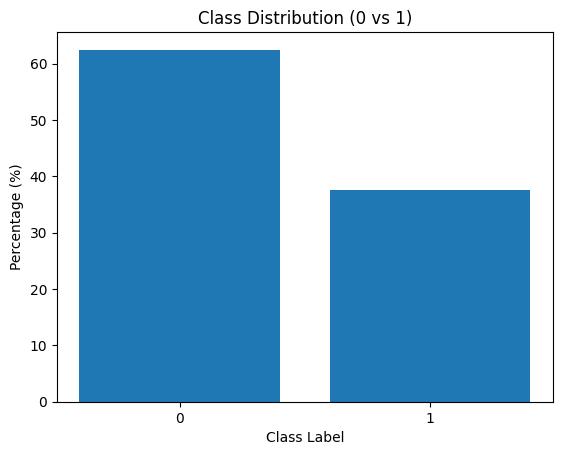

In [ ]:
# import matplotlib.pyplot as plt

# counts = df['label'].value_counts(normalize=True) * 100

# plt.figure()
# plt.bar(counts.index.astype(str), counts.values)
# plt.xlabel("Class Label")
# plt.ylabel("Percentage (%)")
# plt.title("Class Distribution (0 vs 1)")
# plt.show()


In [ ]:
# df.head()
# df['label'].value_counts()


,count
label,
0,333168
1,200313


In [ ]:
from sklearn.utils import resample

df_human = df[df['label'] == 0]
df_ai = df[df['label'] == 1]

df_human_downsampled = resample(
    df_human,
    replace=False,
    n_samples=len(df_ai),
    random_state=42
)

df_balanced = pd.concat([df_human_downsampled, df_ai])
df_balanced = df_balanced.sample(frac=1, random_state=42)  # shuffle


In [ ]:
df_balanced['label'].value_counts()


,count
label,
1,200313
0,200313


In [ ]:
df_balanced.shape

(400626, 2)

In [ ]:
pip install -q transformers datasets torch scikit-learn

In [ ]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
MODEL_NAME = "distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=True,
        max_length=256
    )

In [ ]:
dataset = Dataset.from_pandas(df_balanced)
dataset = dataset.map(tokenize, batched=True)

dataset = dataset.train_test_split(test_size=0.2, seed=42)

dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

Map:   0%|          | 0/400626 [00:00<?, ? examples/s]

In [ ]:
# dataset.save_to_disk("/content/drive/MyDrive/ai_text_detector_dataset")

In [ ]:
from datasets import load_from_disk

dataset = load_from_disk("/content/drive/MyDrive/ai_text_detector_dataset")

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/ai_text_detector_results",
    eval_strategy="steps",          # ✅ MATCHED
    save_strategy="steps",          # ✅ MATCHED
    eval_steps=2000,                # evaluate every 2000 steps
    save_steps=2000,                # save every 2000 steps
    save_total_limit=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir="/content/drive/MyDrive/ai_text_detector_logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    label_smoothing_factor=0.1,
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
2000,0.225773,0.249246,0.977785,0.965635,0.990997,0.978151
4000,0.217723,0.213686,0.993360,0.996248,0.990499,0.993365


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# trainer.train(resume_from_checkpoint=True)

In [ ]:
# test_results = trainer.evaluate(eval_dataset=dataset['test'])
# test_results

In [ ]:
# from sklearn.metrics import confusion_matrix, classification_report
# import numpy as np

# preds = trainer.predict(dataset['test'])
# y_pred = np.argmax(preds.predictions, axis=1)
# y_true = preds.label_ids

# print(classification_report(y_true, y_pred))

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# cm = confusion_matrix(y_true, y_pred)
# sns.heatmap(cm, annot=True, fmt='d')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

In [ ]:
# trainer.save_model("ai_generated_model")
# tokenizer.save_pretrained("ai_generated_model")

In [ ]:
# !cp -r /content/ai_generated_model /content/drive/MyDrive/


In [ ]:
# !ls /content/drive/MyDrive/ai_generated_model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/ai_generated_model"
)
tokenizer = AutoTokenizer.from_pretrained(
    "/content/drive/MyDrive/ai_generated_model"
)


In [ ]:
# import torch

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# def predict_news(text):
#     model.eval()

#     # inputs = tokenizer(
#         text,
#         return_tensors="pt",
#         truncation=True,
#         padding=True
#     )

#     # Move inputs to same device as model
#     inputs = {k: v.to(device) for k, v in inputs.items()}

#     with torch.no_grad():
#         outputs = model(**inputs)

#     pred = torch.argmax(outputs.logits, dim=1).item()
#     return "REAL" if pred == 1 else "FAKE"

In [ ]:
# predict_news("Government announces new education policy for AI development.")

NameError: name 'predict_news' is not defined

In [ ]:
# !pip install fastapi uvicorn nest-asyncio pyngrok

In [ ]:
# %%writefile /content/app.py
# from fastapi import FastAPI
# from pydantic import BaseModel
# import torch
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# MODEL_PATH = "/content/drive/MyDrive/ai_generated_model"

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
# model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
# model.to(device)
# model.eval()

# app = FastAPI()

# class TextRequest(BaseModel):
#     text: str

# @app.post("/predict")
# def predict(req: TextRequest):
#     inputs = tokenizer(req.text, return_tensors="pt", truncation=True, padding=True)
#     inputs = {k: v.to(device) for k, v in inputs.items()}

#     with torch.no_grad():
#         outputs = model(**inputs)
#         probs = torch.softmax(outputs.logits, dim=1)
#         ai_prob = probs[0][1].item()

#     return {
#         "ai_generated_probability": round(ai_prob, 4),
#         "prediction": "AI-GENERATED" if ai_prob > 0.5 else "HUMAN"
#     }

In [ ]:
# !ls /content

In [ ]:
# !uvicorn app:app --host 0.0.0.0 --port 8000

In [ ]:
# from pyngrok import ngrok
# public_url = ngrok.connect(8000)
# print(public_url)

In [ ]:
import joblib
joblib.dump(model, "ai_text_model.pkl")

['ai_text_model.pkl']